In [16]:
import numpy as np
import pandas as pd
import pingouin as pg
import scipy

import seaborn as sns
from matplotlib import pyplot as plt

In [7]:
def cutoff_1d(x, fac=0.5):
    """
    Identify the local minimum of a kernel density estimate of x.
    Used to threshold the differential contextual freezing score (shock - safe)
    and separate RECALLER from NON-RECALLER animals (Fig. 1c).

    Parameters
    ----------
    x   : 1-D array of values (here: contrast_immo per animal)
    fac : KDE bandwidth factor (Scott's Rule multiplier). Default 0.5.

    Returns
    -------
    threshold : float — the first local minimum of the KDE.
    """
    from scipy import stats
    from functools import partial

    def my_kde_bandwidth(obj, fac=1.0 / 5):
        """Scott's Rule multiplied by a constant factor."""
        return np.power(obj.n, -1.0 / (obj.d + 4)) * fac

    kde = stats.gaussian_kde(x, bw_method=partial(my_kde_bandwidth, fac=fac))
    x_eval = np.linspace(x.min() - 1, x.max() + 1, 500)

    import Toolbox.signals.core as sig
    threshold = sig.localminima(kde(x_eval), x=x_eval, method='gradient')[0][0]
    return threshold

# fig1b

Fig. 1b — Paired t-test: immobility change, shock vs. safe context at recall
               T  dof alternative     p_val          CI95   cohen_d   power   BF10
T_test  2.889421   13   two-sided  0.012662  [1.27, 8.83]  0.990705  0.9281  4.682


/tmp/ipykernel_3500236/503075917.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y=var, data=df,
/tmp/ipykernel_3500236/503075917.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='condition', y=var, data=df,
/tmp/ipykernel_3500236/503075917.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set(ylim=(-7.5, 20),


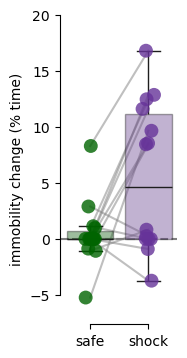

In [8]:
#load data
df = pd.read_parquet('Fig1bc.parquet')

var = 'immobile_idx'

fig, ax = plt.subplots(1, 1, figsize=(1.5, 4))

# Paired lines across animals
lines = (df.set_index(['rat', 'condition'])
           .unstack()
           .reset_index()[var])
for l in np.array(lines):
    ax.plot([0, 1], l, color='grey', alpha=0.5)

ax.axhline(0, color='grey', ls='--')

sns.boxplot(x='condition', y=var, data=df,
            order=['ctrl', 'shock'],
            palette=['darkgreen', 'rebeccapurple'],
            boxprops=dict(alpha=0.4), fliersize=0.0, ax=ax)
sns.stripplot(x='condition', y=var, data=df,
              order=['ctrl', 'shock'],
              palette=['darkgreen', 'rebeccapurple'],
              size=10, alpha=0.8, ax=ax)

ax.set(ylim=(-7.5, 20),
       xticklabels=['safe', 'shock'],
       xlabel='',
       ylabel='immobility change (% time)')
sns.despine(offset=True, trim=True)


# Paired two-sided t-test: change in immobility, shock vs. safe context at recall
results = pg.ttest(
    df.query("condition == 'shock'")[var],
    df.query("condition == 'ctrl'")[var],
    paired=True)

print("Fig. 1b — Paired t-test: immobility change, shock vs. safe context at recall")
print(results.to_string())


# pg.wilcoxon(
#     df.query("condition == 'shock'")[var],
#     df.query("condition == 'ctrl'")[var]
# )

In [18]:
# scipy.stats.shapiro(
scipy.stats.normaltest(
    np.array( df.query("condition == 'shock'")[var]) -  np.array( df.query("condition == 'ctrl'")[var]) )

/home/michon/.conda/envs/analysis/lib/python3.10/site-packages/scipy/stats/_axis_nan_policy.py:430: UserWarning: `kurtosistest` p-value may be inaccurate with fewer than 20 observations; only n=14 observations were given.
  return hypotest_fun_in(*args, **kwds)


NormaltestResult(statistic=np.float64(6.40035799685463), pvalue=np.float64(0.04075490826094066))

# fig1c

/tmp/ipykernel_3500236/2687104712.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='contrast_immo',
/tmp/ipykernel_3500236/2687104712.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(x='contrast_immo',
/tmp/ipykernel_3500236/2687104712.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='condition', y=var,
/tmp/ipykernel_3500236/2687104712.py:43: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

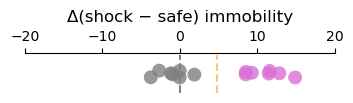

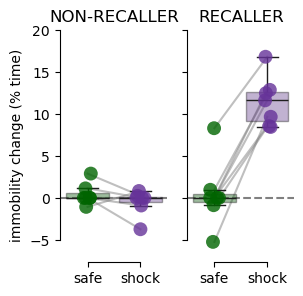

In [4]:
#load data
df = pd.read_parquet('Fig1bc.parquet')

var = 'immobile_idx'

# ── Distribution of Δ(shock − safe) with RECALLER/NON-RECALLER threshold ─────
fig, ax = plt.subplots(1, 1, figsize=(4, 0.5))

ax.axvline(0, color='grey', ls='--')
ax.axvline(cutoff_1d(df.query("session == 'test_shock'")['contrast_immo'], fac=0.5),
           color='darkorange', ls='--', alpha=0.5, label='threshold')

sns.stripplot(x='contrast_immo',
              data=df.query("session == 'test_shock' and context_learning == 'not learned'"),
              y='session', palette=['grey'], size=10, alpha=0.8, ax=ax)
sns.stripplot(x='contrast_immo',
              data=df.query("session == 'test_shock' and context_learning == 'learned'"),
              y='session', palette=['orchid'], size=10, alpha=0.8, ax=ax)

ax.spines['bottom'].set_visible(False)
ax.set(xlim=(-20, 20), yticks=[],
       xlabel='', ylabel='',
       title=u'Δ(shock − safe) immobility')
sns.despine(offset=True, trim=True, left=True, right=True, bottom=True, top=False)

# ── Freezing change split by recall status (NON-RECALLER | RECALLER) ──────────
fig, ax = plt.subplots(1, 2, figsize=(3, 3), sharey=True, sharex=True)

for l, (learn, label) in enumerate([('not learned', 'NON-RECALLER'), ('learned', 'RECALLER')]):
    lines = (df.query("context_learning == '{}'".format(learn))
               .set_index(['rat', 'condition'])
               .unstack()
               .reset_index()[var])
    for c in np.array(lines):
        ax[l].plot([0, 1], c, color='grey', alpha=0.5)

    ax[l].axhline(0, color='grey', ls='--')
    sns.boxplot(x='condition', y=var,
                data=df.query("context_learning == '{}'".format(learn)),
                order=['ctrl', 'shock'],
                palette=['darkgreen', 'rebeccapurple'],
                boxprops=dict(alpha=0.4), fliersize=0.0, ax=ax[l])
    sns.stripplot(x='condition', y=var,
                  data=df.query("context_learning == '{}'".format(learn)),
                  order=['ctrl', 'shock'],
                  palette=['darkgreen', 'rebeccapurple'],
                  size=10, alpha=0.8, ax=ax[l])
    ax[l].set(ylim=(-7.5, 20),
              xticklabels=['safe', 'shock'],
              xlabel='', ylabel='', title=label)

ax[0].set(ylabel='immobility change (% time)')
sns.despine(offset=True, trim=True)